=== OPTIMIZED RESULTS ===
Best burn time: 300.0 seconds
Max altitude: 2267.1 km
Max velocity: 6.908 km/s


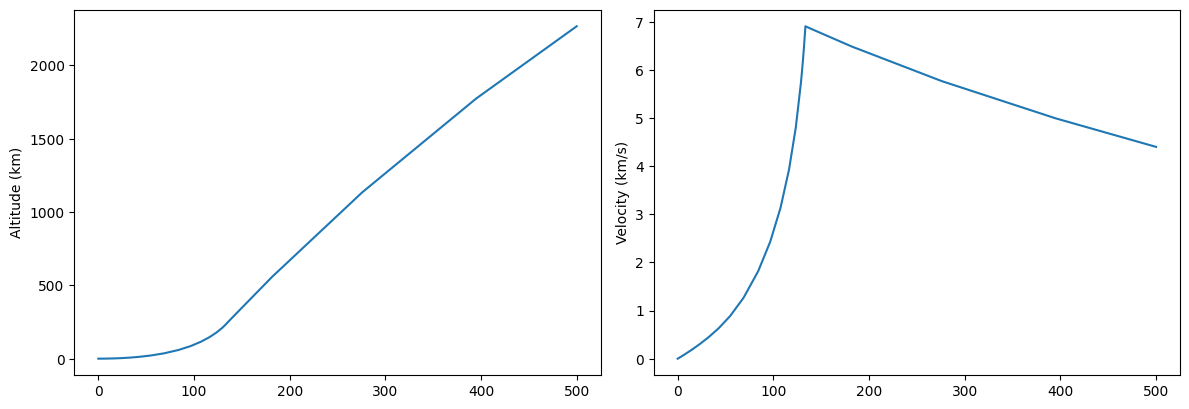

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# Parameters
G = 9.81
R_EARTH = 6371000
m_dry = 25000
m_fuel = 350000
Isp = 311
ve = Isp * G
thrust = 8_000_000

def simulate_rocket(burn_time):
    def rocket_dynamics(t, y):
        altitude, velocity, mass = y
        g = G * (R_EARTH / (R_EARTH + altitude))**2
        rho = 1.225 * np.exp(-altitude / 8500)

        if t < burn_time and mass > m_dry:
            thrust_force = thrust
            mass_rate = -thrust / ve
        else:
            thrust_force = 0
            mass_rate = 0

        drag = 0.5 * 0.3 * rho * 25 * velocity**2
        acceleration = (thrust_force - drag - mass * g) / mass if mass > 0 else -g
        return [velocity, acceleration, mass_rate]

    y0 = [0.0, 0.0, m_dry + m_fuel]
    sol = solve_ivp(rocket_dynamics, [0, 500], y0, method='RK45', rtol=1e-6, atol=1e-6)
    final_velocity = sol.y[1][-1]
    max_alt = max(sol.y[0])
    return -final_velocity, max_alt, sol  # Negative for optimization

# Optimize burn time
result = minimize_scalar(lambda bt: simulate_rocket(bt)[0], bounds=(100, 300), method='bounded')
best_burn_time = result.x
_, best_alt, best_sol = simulate_rocket(best_burn_time)

print("=== OPTIMIZED RESULTS ===")
print("Best burn time:", round(best_burn_time, 1), "seconds")
print("Max altitude:", round(max(best_sol.y[0])/1000, 2), "km")
print("Max velocity:", round(max(best_sol.y[1])/1000, 3), "km/s")

# Plot (optional - you can run this part separately)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(best_sol.t, best_sol.y[0]/1000)
plt.ylabel('Altitude (km)')
plt.subplot(2, 2, 2)
plt.plot(best_sol.t, best_sol.y[1]/1000)
plt.ylabel('Velocity (km/s)')
plt.tight_layout()
plt.show()
